# Deep Learning for Finance - Student Lab



This lab will aim to find a way to predict the stock price movement and patterns through different Deep Learning architectures, and see how well they perform on financial data. The dataset used here spans from 1998 and ends in May of 2025.

## Libraries and Setup



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from library import (
    create_train_val_test_loaders,
    CombinedLoss,
    train_model,
    evaluate_and_visualize_model,
 )

# Configuration
CSV_FALLBACK = "xyz_stock.csv"
# Set random seeds for reproducibility
np.random.seed(135166)
torch.manual_seed(135166)

# Overall parameters
MAX_EPOCHS = 60
SEQ_LEN_RAW = 15  # e.g., 15 hours (modified afterwards)

## Data and features building

In [3]:
xyz_stock = pd.read_csv(CSV_FALLBACK, parse_dates=['date'], index_col='date')
xyz_stock.head()

,close,volume,rsi_14,volatility_10,return,target_ret_next,vol_5,vol_10,vol_20,ema_10,ema_20,ema_50
date,,,,,,,,,,,,
1998-01-22,72.981640,1.146893e+06,58.803698,1.693321,-0.000159,0.004228,0.011222,0.020136,0.016733,0.005350,-0.010348,-0.037133
1998-01-23,72.970068,1.552437e+06,58.765877,1.222167,0.004228,-0.019391,0.011962,0.019162,0.016342,0.004508,-0.009221,-0.035530
1998-01-24,73.278576,1.046712e+06,61.207981,1.191705,-0.019391,-0.004643,0.005198,0.014775,0.016220,0.000228,-0.012117,-0.038038
1998-01-25,71.857608,8.448196e+05,56.526749,1.365281,-0.004643,0.001007,0.009042,0.015114,0.017020,0.016370,0.006712,-0.018270
1998-01-26,71.523990,8.200005e+05,51.278831,1.504362,0.001007,-0.003164,0.008917,0.014665,0.015551,0.017272,0.010321,-0.013154


In [4]:
i_train = int(0.70 * len(xyz_stock))
i_val = int(0.85 * len(xyz_stock))
train_df = xyz_stock.iloc[:i_train].copy()
val_df = xyz_stock.iloc[i_train:i_val].copy()
test_df = xyz_stock.iloc[i_val:].copy()

['close',
 'volume',
 'rsi_14',
 'volatility_10',
 'return',
 'target_ret_next',
 'vol_5',
 'vol_10',
 'vol_20',
 'ema_10',
 'ema_20',
 'ema_50']

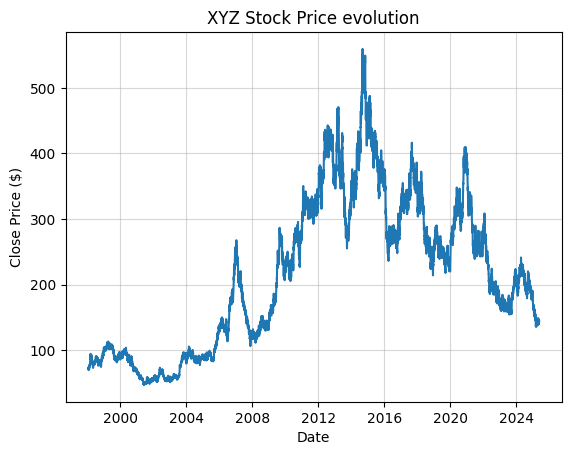

In [5]:
# Plot the share price over the full time period
X = xyz_stock.index
Y = xyz_stock['close']
plt.title("XYZ Stock Price evolution")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(alpha = 0.5)
plt.plot(X,Y)

# List of the technical indicators that have been precomputed
xyz_stock.columns.tolist()

# MLP

In [6]:
BATCH_SIZE = 64 # how many samples per batch
HIDDEN_LAYERS = [64, 32] # Hidden layers architecture
DROPOUT = 0.3 # Dropout rate for regularization
WEIGHT_DECAY = 1e-5  # Weight decay for regularization
LEARNING_RATE = 0.0008 # Learning rate for the optimizer
SEQ_LEN_RAW = 15  # here 15 hours for the raw price data

In [7]:
class PriceMLP(nn.Module):
    def __init__(self, seq_len, num_features, hidden_layers, dropout):
        super().__init__()
        input_dim = seq_len * num_features
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [ ]:
# Create data loaders
raw_price_cols = ['close'] # use only close here
train_raw_loader, val_raw_loader, test_raw_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=raw_price_cols,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE
)

# Initialize model, optimizer, and loss function and load it to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# You may use AdamW optimizer and CombinedLoss as loss function
raw_model = PriceMLP(SEQ_LEN_RAW, len(raw_price_cols), hidden_layers=HIDDEN_LAYERS, dropout=DROPOUT).to(device)
raw_optimizer = torch.optim.AdamW(raw_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
raw_loss_fn = CombinedLoss()

# Train the raw price model, you can use the train_model function given in the utilities
best_val, test_mse = train_model(
    model=raw_model,
    train_loader=train_raw_loader,
    val_loader=val_raw_loader,
    test_loader=test_raw_loader,
    optimizer=raw_optimizer,
    loss_fn=raw_loss_fn,
    device=device,
    save_path="best_MLP_raw_price.pt",
    max_epochs=MAX_EPOCHS,
    patience=10,
    print_every=5
)

c:\Users\eleni\OneDrive\Desktop\Columbia\Artificial Intelligence for Financial Engineering and Operations Research\Lab 2\library.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  self.sequences = torch.tensor(self.sequences, dtype=torch.float32)


Train samples: 6969
Val samples: 1482
Test samples: 1482

Input shape: (15, 1) = 15 hours x 1 features

Training PriceMLP started...
Epoch 01 | Train MSE: 0.486264 | Val MSE: 0.485173 | Train Acc: 50.14% | Val Acc: 51.75% | Patience: 10
Epoch 05 | Train MSE: 0.485408 | Val MSE: 0.485197 | Train Acc: 50.50% | Val Acc: 50.88% | Patience: 7
Epoch 10 | Train MSE: 0.485325 | Val MSE: 0.485284 | Train Acc: 50.54% | Val Acc: 50.88% | Patience: 2

Early stopping at epoch 12

Best validation MSE: 0.485167, Test MSE: 0.485256
Test directional accuracy: 50.00%



STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:           -35.52%
Annualized Return:       -7.19%
Annualized Vol:          23.31%
Sharpe Ratio:            -0.204
Max Drawdown:           -43.73%
Win Rate:                49.03%
Active Days:               1134 / 1482

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -49.62%
Sharpe Ratio:            -0.302

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:           14.10%
Sharpe Improvement:       0.099


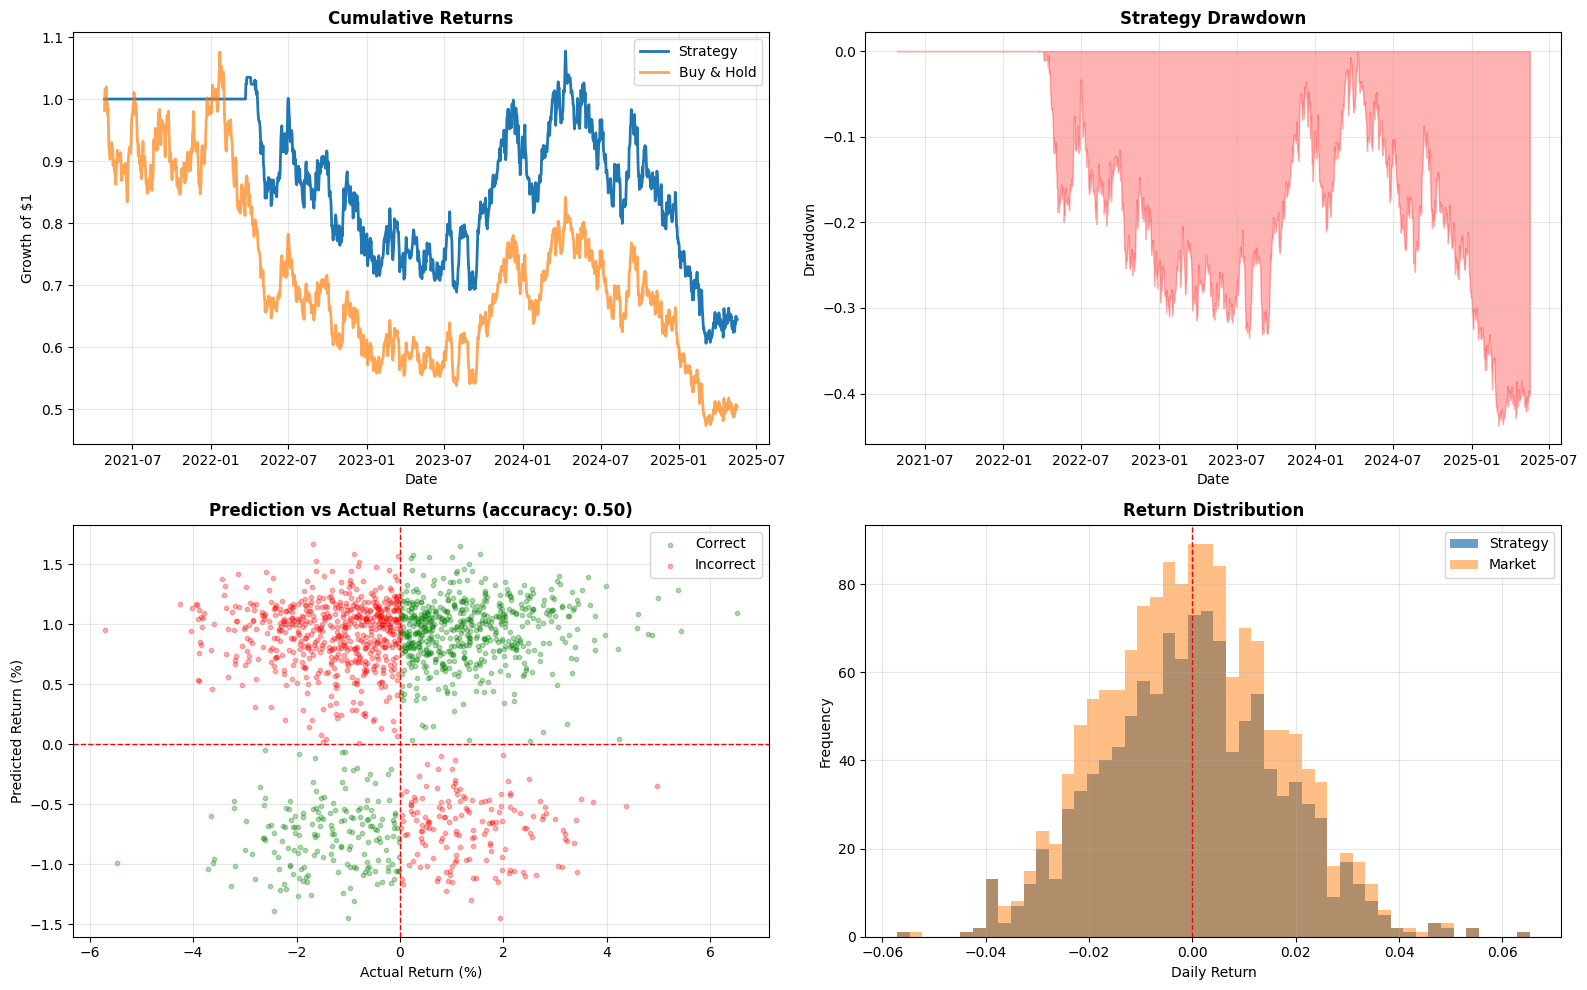

In [9]:
# getting results predictions on the test set and evaluating strategy
raw_model.load_state_dict(torch.load("best_MLP_raw_price.pt", map_location=device))
raw_model.eval()

strategy_metrics_mlp_raw = evaluate_and_visualize_model(raw_model, test_raw_loader, test_df, device)

## With feature engineering

In [10]:
BATCH_SIZE = 32
HIDDEN_LAYERS = [64, 32]  # Two hidden layers
DROPOUT = 0.2
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5  # 0.00001

In [11]:
feature_columns = ['close','volume','rsi_14','vol_5','vol_10','vol_20','ema_10','ema_20','ema_50']
SEQ_LEN_RAW = 1 # use 1 hour sequence for engineered features as the past view is in the features
# Create data loaders
train_feature_loader, val_feature_loader, test_feature_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=feature_columns,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE
)

Train samples: 6983
Val samples: 1496
Test samples: 1496

Input shape: (1, 9) = 1 hours x 9 features


In [ ]:
# Initialize model, optimizer, and loss function and load it to the device, you can reuse the PriceMLP class defined earlier
print("Initializing feature model")
feature_model = PriceMLP(SEQ_LEN_RAW, len(feature_columns), hidden_layers=HIDDEN_LAYERS, dropout=DROPOUT).to(device)
feature_optimizer = torch.optim.AdamW(feature_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
feature_loss_fn = CombinedLoss()

print("Feature model initialized")

# Train the feature model
best_val, test_mse = train_model(model=feature_model, train_loader=train_feature_loader, val_loader=val_feature_loader, test_loader=test_feature_loader, optimizer=feature_optimizer, loss_fn=feature_loss_fn, device=device, save_path="best_MLP_feature.pt", max_epochs=MAX_EPOCHS, patience=10, print_every=1) # type: ignore

Initializing feature model
Feature model initialized

Training PriceMLP started...
Epoch 01 | Train MSE: 0.488763 | Val MSE: 0.485476 | Train Acc: 49.71% | Val Acc: 51.00% | Patience: 10
Epoch 02 | Train MSE: 0.485992 | Val MSE: 0.485288 | Train Acc: 50.52% | Val Acc: 51.74% | Patience: 10
Epoch 03 | Train MSE: 0.485776 | Val MSE: 0.485235 | Train Acc: 51.44% | Val Acc: 51.54% | Patience: 10
Epoch 04 | Train MSE: 0.485155 | Val MSE: 0.485177 | Train Acc: 52.28% | Val Acc: 51.67% | Patience: 10
Epoch 05 | Train MSE: 0.484934 | Val MSE: 0.485165 | Train Acc: 52.79% | Val Acc: 52.47% | Patience: 10
Epoch 06 | Train MSE: 0.485079 | Val MSE: 0.485131 | Train Acc: 52.51% | Val Acc: 53.21% | Patience: 10
Epoch 07 | Train MSE: 0.484983 | Val MSE: 0.485297 | Train Acc: 52.61% | Val Acc: 52.14% | Patience: 9
Epoch 08 | Train MSE: 0.484753 | Val MSE: 0.485442 | Train Acc: 53.06% | Val Acc: 52.47% | Patience: 8
Epoch 09 | Train MSE: 0.484740 | Val MSE: 0.485492 | Train Acc: 53.39% | Val Acc: 50.53


STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:            -7.01%
Annualized Return:       -1.22%
Annualized Vol:          19.24%
Sharpe Ratio:             0.032
Max Drawdown:           -43.25%
Win Rate:                50.32%
Active Days:                771 / 1496

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -54.23%
Sharpe Ratio:            -0.359

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:           47.22%
Sharpe Improvement:       0.391


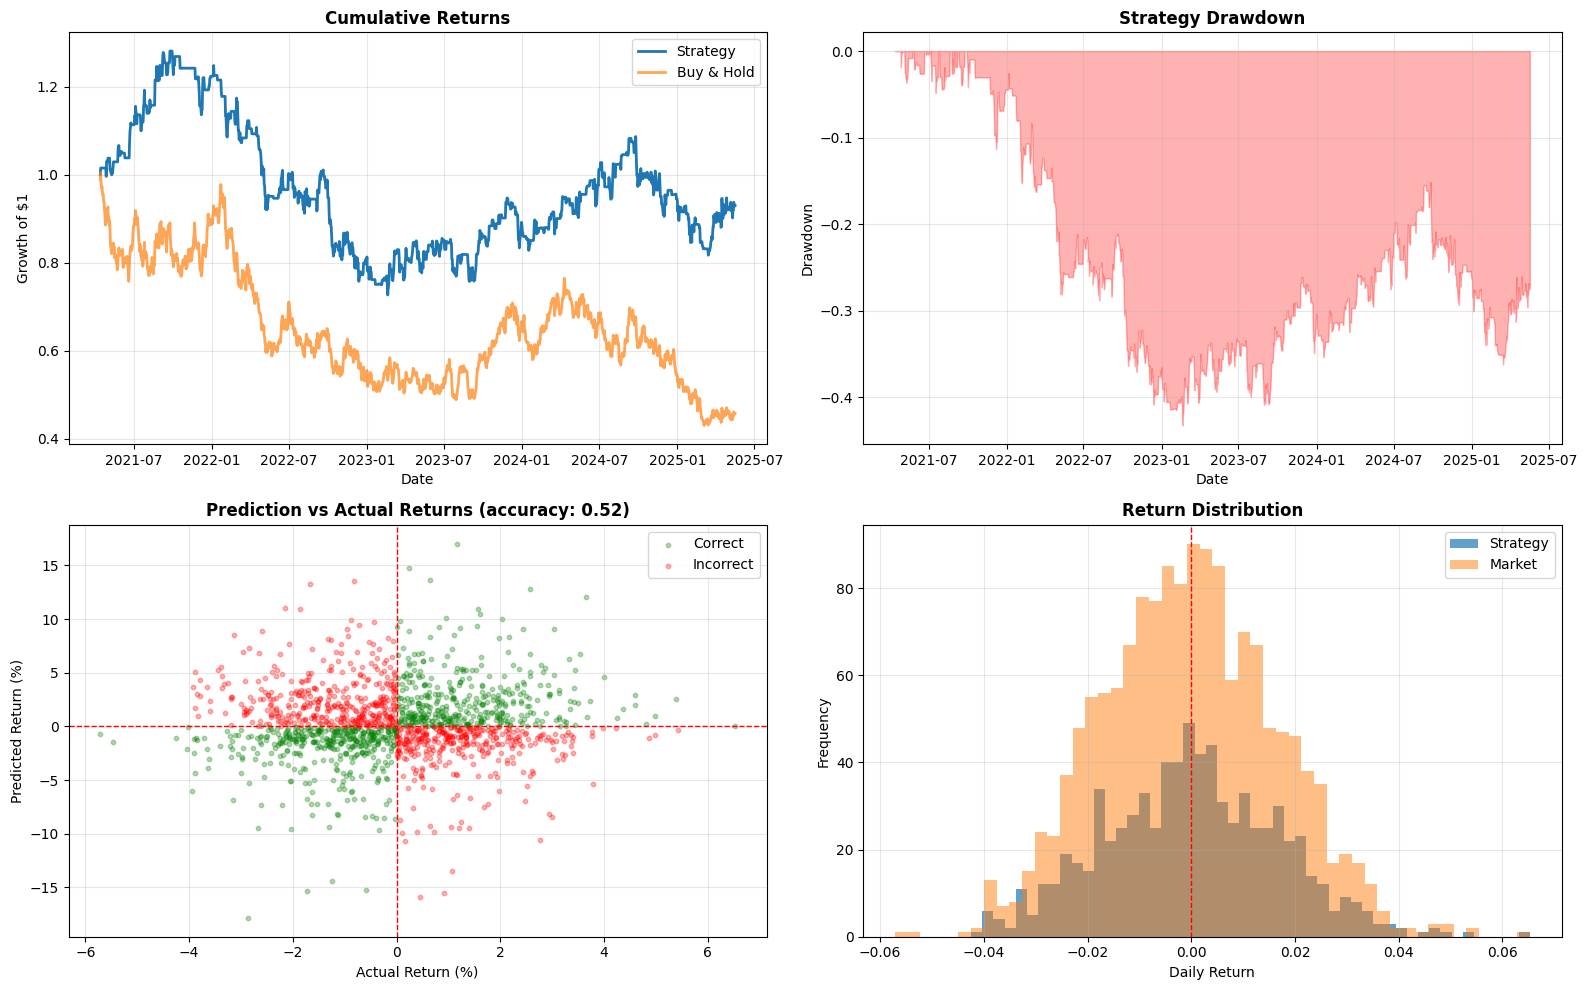

In [13]:
# getting results predictions on the test set and evaluating strategy
feature_model.load_state_dict(torch.load("best_MLP_feature.pt", map_location=device))
feature_model.eval()

strategy_metrics_mlp_features = evaluate_and_visualize_model(feature_model, test_feature_loader, test_df, device)

# LSTM Model for Time Series Prediction

In [17]:
class PriceEMALSTM(nn.Module):
    """
    LSTM model for sequential price + EMA data.
    Input: (batch, seq_len, 8) where 8 = [open, high, low, close, volume, ema_10, ema_20, ema_50]
    """
    def __init__(self,
                 input_dim=8,
                 hidden_dim=64,
                 num_layers=2,
                 fc_hidden_dims=[32, 16],
                 dropout=0.2):
        super().__init__()

        # Initialize the LSTM model
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 1. Layer Normalization
        self.layer_norm = nn.LayerNorm(input_dim) 
       
        # 2. LSTM layer(s)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers >1 else 0)

        # 3. Fully connected layers (MLP) for output
        layers = []
        curr_dim = hidden_dim
        for h_dim in fc_hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, 1))
        self.fc_head = nn.Sequential(*layers)
       

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)

        # Implement forward pass
        # 1. Normalize input
        x = self.layer_norm(x)

        # 2. Pass through LSTM
        lstm_out, _ = self.lstm(x)

        # 3. Use the last hidden state
        last_hidden_state = lstm_out[:, -1, :]

        # 4. Pass through MLP to get prediction
        output = self.fc_head(last_hidden_state)
        return output

In [18]:
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
FC_HIDDEN_DIMS = [32, 16]
DROPOUT = 0.2
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5  # 0.00001

In [19]:
feature_columns = ['close','volume','rsi_14','vol_5','vol_10','vol_20', 'ema_10','ema_20','ema_50']
SEQ_LEN_RAW = 10 # use 1 hour sequence for engineered features as the past view is in the features
# Create data loaders
train_lstm_loader, val_lstm_loader, test_lstm_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=feature_columns,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE
)

Train samples: 6974
Val samples: 1487
Test samples: 1487

Input shape: (10, 9) = 10 hours x 9 features


In [22]:
# Initialize model, optimizer, and loss function and load it to the device
# You may use AdamW optimizer and CombinedLoss as loss function
lstm_model = PriceEMALSTM(input_dim=len(feature_columns), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, fc_hidden_dims=FC_HIDDEN_DIMS, dropout=DROPOUT).to(device)
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
lstm_loss_fn = CombinedLoss()

In [ ]:
# Train the LSTM model
best_val, test_mse = train_model(model=lstm_model, train_loader=train_feature_loader, val_loader=val_feature_loader, test_loader=test_feature_loader, optimizer=lstm_optimizer, loss_fn=lstm_loss_fn, device=device, save_path="best_lstm.pt", max_epochs=MAX_EPOCHS, patience=10, print_every=5) # type: ignore


Training PriceEMALSTM started...
Epoch 01 | Train MSE: 0.485428 | Val MSE: 0.485233 | Train Acc: 49.78% | Val Acc: 51.00% | Patience: 10
Epoch 05 | Train MSE: 0.485182 | Val MSE: 0.485123 | Train Acc: 50.87% | Val Acc: 52.27% | Patience: 10
Epoch 10 | Train MSE: 0.484925 | Val MSE: 0.485508 | Train Acc: 53.03% | Val Acc: 50.07% | Patience: 5
Epoch 15 | Train MSE: 0.484721 | Val MSE: 0.485722 | Train Acc: 53.56% | Val Acc: 48.60% | Patience: 0

Early stopping at epoch 15

Best validation MSE: 0.485123, Test MSE: 0.485120
Test directional accuracy: 53.14%



STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:             1.83%
Annualized Return:        0.31%
Annualized Vol:          16.75%
Sharpe Ratio:             0.102
Max Drawdown:           -31.02%
Win Rate:                50.35%
Active Days:                574 / 1487

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -51.27%
Sharpe Ratio:            -0.322

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:           53.10%
Sharpe Improvement:       0.423


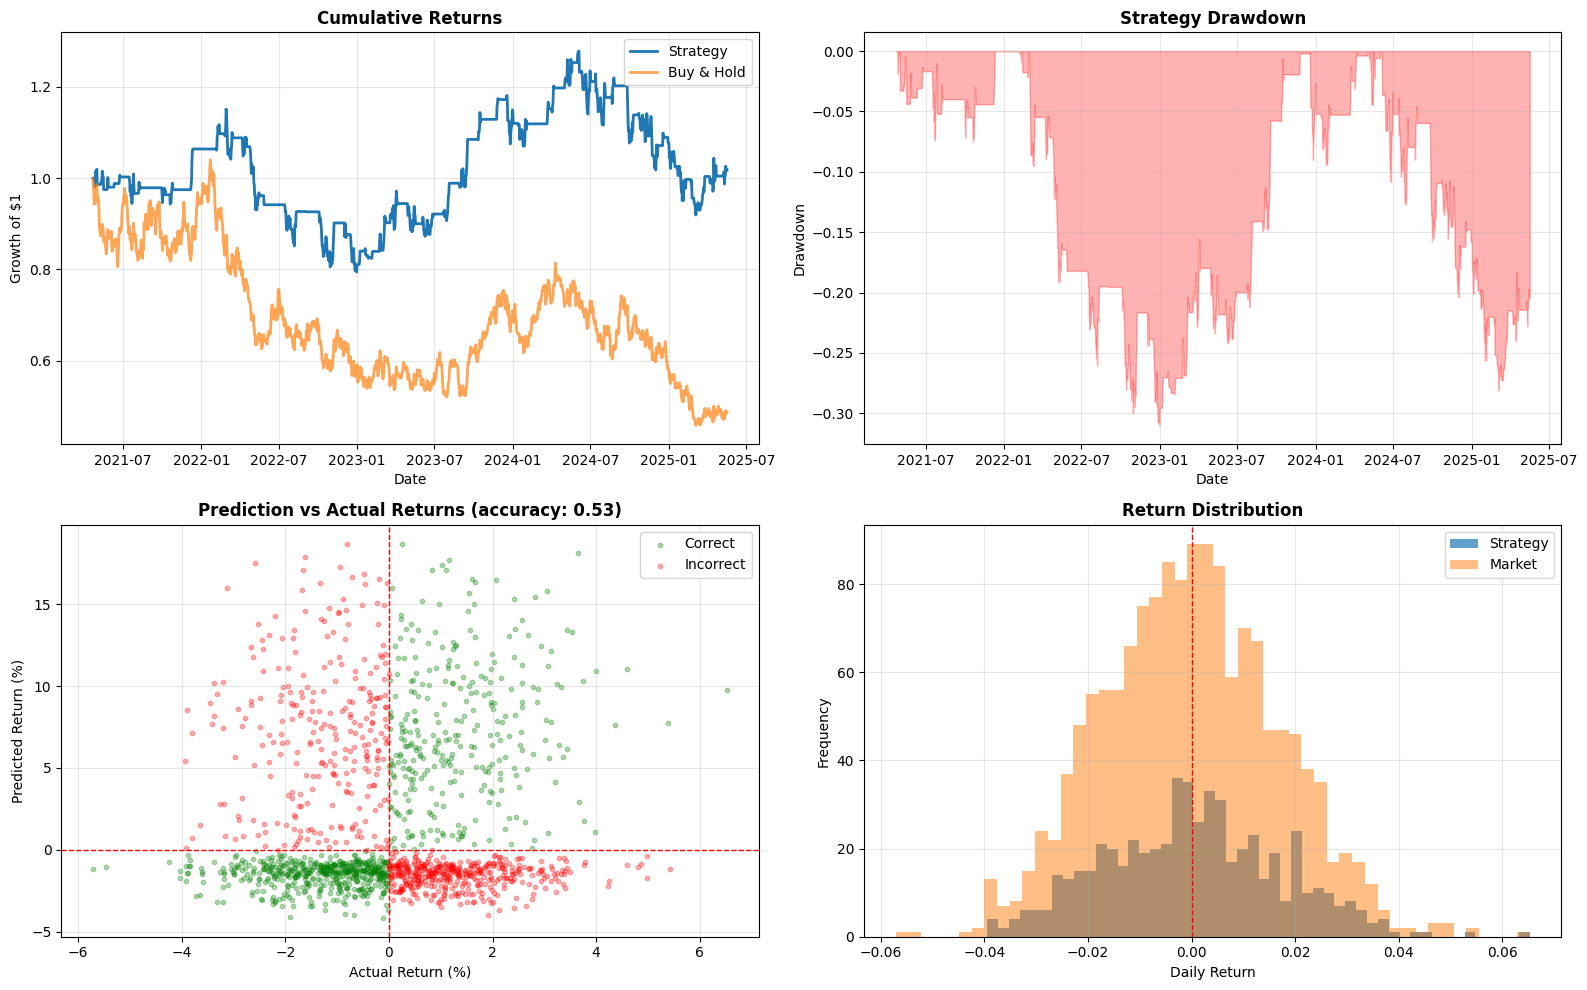

In [24]:
# getting results predictions on the test set and evaluating strategy
lstm_model.load_state_dict(torch.load("best_lstm.pt", map_location=device))
lstm_model.eval()

strategy_metrics_lstm = evaluate_and_visualize_model(lstm_model, test_lstm_loader, test_df, device)

# Transformer model

In [25]:
BATCH_SIZE = 64
feature_cols = ['close','volume','rsi_14','vol_5','vol_10','vol_20','ema_10','ema_20','ema_50']
SEQ_LEN_RAW = 20  # e.g., 20 hours
input_dim = len(feature_cols)

# architecture
custom_config = {
    'd_model': 32,           #
    'nhead': 2,              #  (must divide d_model)
    'num_layers': 2,         #
    'dim_feedforward': 32,   #
    'fc_hidden_dims': [32, 32],  #  (e.g., [32, 32] for two layers)
    'dropout': 0.2,          #
    'use_residual': True     #
}

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096, dropout: float = 0.0):
        super().__init__()
        #Implement Positional Encoding
        #Sinusoidal Positional Encoding
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model) #matrix [max_len, d_model] to store the positional encodings
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) #matrix [max_len, 1] to store the positions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)) #matrix [d_model/2] to store the division terms
        pe[:, 0::2] = torch.sin(position * div_term) #apply sin to even indices
        pe[:, 1::2] = torch.cos(position * div_term) #apply cos to odd indices
        pe = pe.unsqueeze(0) #add batch dimension 
        self.register_buffer('pe', pe) #register_buffer ensures that 'pe' is saved as part of the model but not trained by the optimizer


    def forward(self, x):
        #Add positional encoding to input x
        x = x + self.pe[:, :x.size(1)] 
        return self.dropout(x) #apply dropout

class PriceTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        fc_hidden_dims = [32],
        dropout: float = 0.1,
        use_residual: bool = True,
        pooling: str = 'mean'  # 'mean' or 'last'
    ):
        super().__init__()
        # Initialize Transformer model
        self.pooling = pooling
        # 1. Input projection (Linear)
        self.input_projection = nn.Linear(input_dim, d_model)
        # 2. Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        # 3. Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        # 4. Output Head (MLP)
        layers = []
        curr_dim = d_model
        for h_dim in fc_hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, 1))
        self.fc_head = nn.Sequential(*layers)

    def forward(self, x):
        # Implement forward pass

        # Input projection
        x = self.input_projection(x)
        
        #Positional encoding
        x = self.pos_encoder(x)

        #Pass through the transformers layers
        x = self.transformer_encoder(x)

        #Pooling
        if self.pooling == 'mean':
            x=x.mean(dim=1)
        else:
            x = x[:, -1, :]

        return self.fc_head(x)

In [50]:
# Dataloaders for Transformer using engineered features
transformer_train_loader, transformer_val_loader, transformer_test_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=feature_cols,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE
)

print(f"Transformer Input shape: ({SEQ_LEN_RAW}, {len(feature_cols)})")

Train samples: 6964
Val samples: 1477
Test samples: 1477

Input shape: (20, 9) = 20 hours x 9 features
Transformer Input shape: (20, 9)


In [ ]:
# Initialize Transformer model from custom_config and train

tconf = custom_config

# Initialize model, optimizer, and loss function and load it to the device
# You may use AdamW optimizer and CombinedLoss as loss function
transformer_model = PriceTransformer(
    input_dim=len(feature_cols),
    d_model=tconf['d_model'],
    nhead=tconf['nhead'],
    num_layers=tconf['num_layers'],
    dim_feedforward=tconf['dim_feedforward'],
    fc_hidden_dims=tconf['fc_hidden_dims'],
    dropout=tconf['dropout'],
    use_residual=tconf['use_residual'],
    pooling='mean'
).to(device)
transformer_optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
transformer_loss_fn = CombinedLoss()

# Train the Transformer model
best_val_tf, test_mse_tf = train_model(model=transformer_model, train_loader=transformer_train_loader, val_loader=transformer_val_loader, test_loader=transformer_test_loader, optimizer=transformer_optimizer, loss_fn=transformer_loss_fn, device=device, save_path="best_transformer.pth", max_epochs=MAX_EPOCHS, patience=10, print_every=5) # type: ignore


Training PriceTransformer started...
Epoch 01 | Train MSE: 0.486736 | Val MSE: 0.485287 | Train Acc: 50.36% | Val Acc: 51.12% | Patience: 10
Epoch 05 | Train MSE: 0.485487 | Val MSE: 0.485247 | Train Acc: 50.60% | Val Acc: 51.39% | Patience: 8
Epoch 10 | Train MSE: 0.485178 | Val MSE: 0.485370 | Train Acc: 51.44% | Val Acc: 50.71% | Patience: 3

Early stopping at epoch 13

Best validation MSE: 0.485117, Test MSE: 0.485339
Test directional accuracy: 49.63%



STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:           -43.03%
Annualized Return:       -9.15%
Annualized Vol:          24.37%
Sharpe Ratio:            -0.272
Max Drawdown:           -52.38%
Win Rate:                49.05%
Active Days:               1205 / 1477

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -50.59%
Sharpe Ratio:            -0.316

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:            7.56%
Sharpe Improvement:       0.044


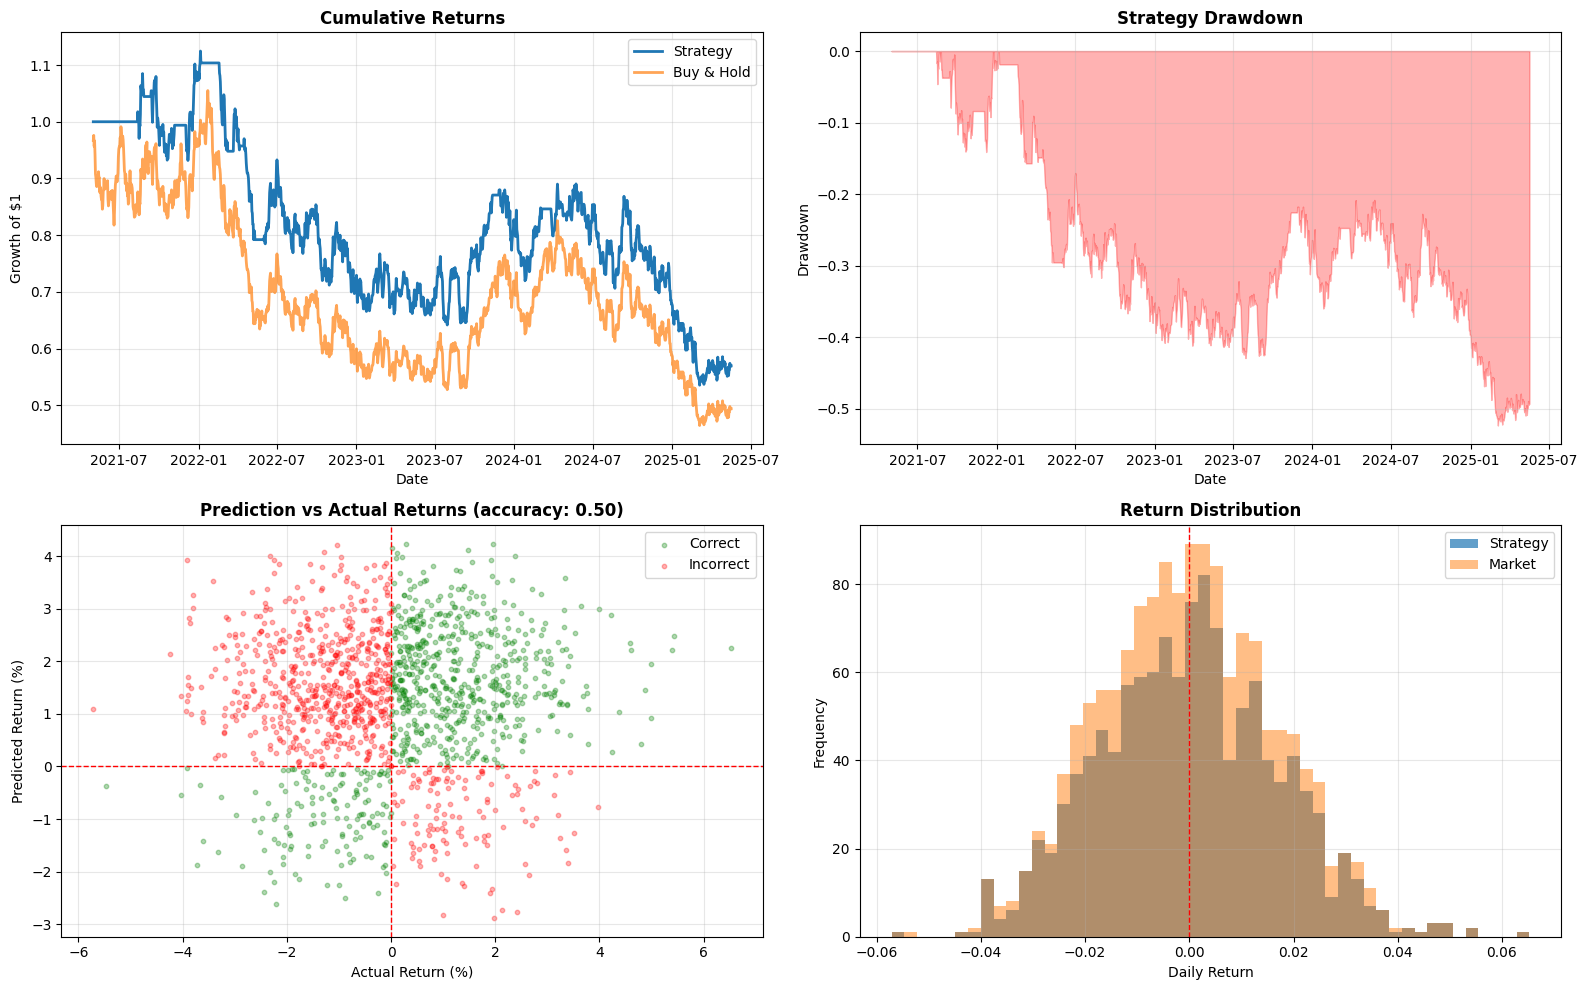

In [52]:
# Evaluate Transformer strategy and visualize

# Load best weights and evaluate on test set
transformer_model.load_state_dict(torch.load("best_transformer.pth", map_location=device))
transformer_model.eval()

strategy_metrics_tf = evaluate_and_visualize_model(transformer_model, transformer_test_loader, test_df, device)

# Using a RNN

In [66]:
BATCH_SIZE = 64
feature_cols = ['close','volume','rsi_14','vol_5','vol_10','vol_20','ema_10','ema_20','ema_50']
SEQ_LEN_RAW = 20  # e.g., 20 hours
input_dim = len(feature_cols)

In [ ]:
class PriceRNN(nn.Module):
    """
    Vanilla RNN or GRU model for sequential price prediction.
    Can use either RNN or GRU cells.
    """
    def __init__(self,
                 input_dim=9,
                 hidden_dim=64,
                 num_layers=2,
                 fc_hidden_dims=[32, 16],
                 dropout=0.2,
                 rnn_type='RNN'):  # 'RNN' or 'GRU'
        super().__init__()

        # Initialize RNN/GRU model

        self.rnn_type = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Input projection
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        
        # RNN or GRU layer
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        else:
            raise ValueError("rnn_type must be 'RNN' or 'GRU'")
        
        # Output head (MLP)
        layers = []
        curr_dim = hidden_dim
        for h_dim in fc_hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, 1))
        self.fc_head = nn.Sequential(*layers)

    def forward(self, x):
        # Implement forward pass
        
        # Input projection
        x = self.input_projection(x)
        
        # RNN or GRU layer
        out, _ = self.rnn(x)
        
        # Use the last output for prediction
        out = out[:, -1, :]
        
        # Pass through MLP head
        out = self.fc_head(out)
        
        return out

In [ ]:
# RNN Configuration and Training

BATCH_SIZE_RNN = 32
HIDDEN_DIM_RNN = 64
NUM_LAYERS_RNN = 2
FC_HIDDEN_DIMS_RNN = [32, 16]
DROP_OUT_RNN = 0.2
LEARNING_RATE_RNN = 0.001
WEIGHT_DECAY_RNN = 1e-5
SEQ_LEN_RAW = 15

feature_columns = ['close','volume','rsi_14','vol_5','vol_10','vol_20', 'ema_10','ema_20','ema_50']

# Create dataloaders
train_rnn_loader, val_rnn_loader, test_rnn_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=feature_columns,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE_RNN
)

print(f"\nInitializing RNN (GRU) model...")

# Initialize model, optimizer, and loss function and load it to the device
# You may use AdamW optimizer and CombinedLoss as loss function
rnn_model = PriceRNN(input_dim=len(feature_columns), hidden_dim=HIDDEN_DIM_RNN, num_layers=NUM_LAYERS_RNN, fc_hidden_dims=FC_HIDDEN_DIMS_RNN, dropout=DROP_OUT_RNN, rnn_type='GRU').to(device)
rnn_optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE_RNN, weight_decay=WEIGHT_DECAY_RNN)
rnn_loss_fn = CombinedLoss()

print("Training RNN model...\n")
best_val_rnn, test_mse_rnn = train_model(model=rnn_model, train_loader=train_rnn_loader, val_loader=val_rnn_loader, test_loader=test_rnn_loader, optimizer=rnn_optimizer, loss_fn=rnn_loss_fn, device=device, save_path="best_rnn.pt", max_epochs=MAX_EPOCHS, patience=10, print_every=5) # type: ignore

Train samples: 6969
Val samples: 1482
Test samples: 1482

Input shape: (15, 9) = 15 hours x 9 features

Initializing RNN (GRU) model...
Training RNN model...


Training PriceRNN started...
Epoch 01 | Train MSE: 0.487961 | Val MSE: 0.485278 | Train Acc: 49.68% | Val Acc: 51.08% | Patience: 10
Epoch 05 | Train MSE: 0.485575 | Val MSE: 0.485482 | Train Acc: 50.72% | Val Acc: 51.96% | Patience: 9
Epoch 10 | Train MSE: 0.484857 | Val MSE: 0.485683 | Train Acc: 53.24% | Val Acc: 50.13% | Patience: 6
Epoch 15 | Train MSE: 0.483460 | Val MSE: 0.488028 | Train Acc: 55.02% | Val Acc: 50.74% | Patience: 1

Early stopping at epoch 16

Best validation MSE: 0.485048, Test MSE: 0.485277
Test directional accuracy: 50.67%



RNN (GRU) MODEL PERFORMANCE

STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:           -36.49%
Annualized Return:       -7.43%
Annualized Vol:          17.90%
Sharpe Ratio:            -0.342
Max Drawdown:           -45.91%
Win Rate:                48.67%
Active Days:                676 / 1482

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -49.62%
Sharpe Ratio:            -0.302

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:           13.13%
Sharpe Improvement:      -0.040


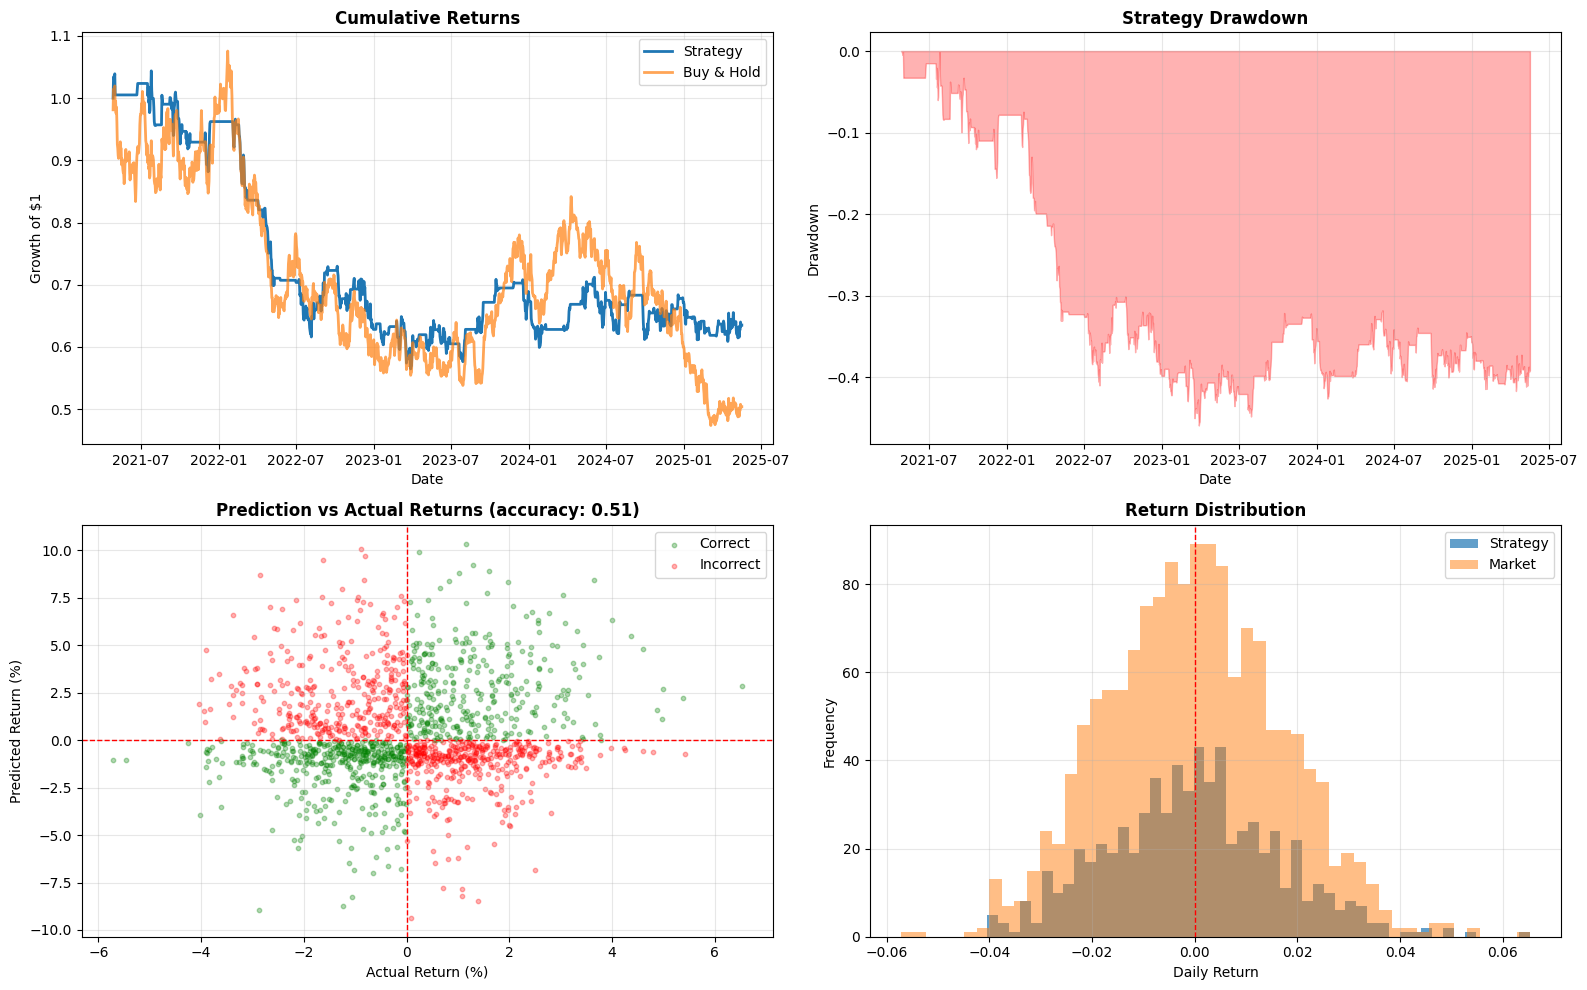

In [69]:
# Evaluate RNN strategy and visualize

rnn_model.load_state_dict(torch.load("best_rnn.pt", map_location=device))
rnn_model.eval()

print("\n" + "="*80)
print("RNN (GRU) MODEL PERFORMANCE")
print("="*80)

strategy_metrics_rnn = evaluate_and_visualize_model(rnn_model, test_rnn_loader, test_df, device)

## CNN Model for Time Series

In [ ]:
class PriceCNN(nn.Module):
    """
    1D Convolutional Neural Network for time series prediction.
    Uses multiple Conv1D layers to extract temporal patterns.
    """
    def __init__(self,
                 input_dim=9,
                 conv_channels=[32, 64, 128],
                 kernel_sizes=[3, 3, 3],
                 fc_hidden_dims=[64, 32],
                 dropout=0.2,
                 pooling='adaptive',
                 seq_len=15):  # 'adaptive' or 'global_avg'
        super().__init__()

        # Initialize CNN model
        self.conv_layers = nn.ModuleList()
        self.batch_norm = nn.ModuleList()
        self.dropout = nn.ModuleList()
        self.pooling = pooling
        # 1. Batch Norm
        self.bn = nn.BatchNorm1d(input_dim)

        # 2. Convolutional layers (Conv1d + BatchNorm + ReLU + Dropout)
        for i in range(len(conv_channels)):
            self.conv_layers.append(nn.Conv1d(input_dim if i == 0 else conv_channels[i-1], conv_channels[i], kernel_sizes[i]))
            self.batch_norm.append(nn.BatchNorm1d(conv_channels[i]))
            self.dropout.append(nn.Dropout(dropout))

        # 3. Pooling
        if pooling == 'adaptive':
            self.pool = nn.AdaptiveAvgPool1d(1)
        elif pooling == 'global_avg':
            self.pool = nn.AvgPool1d(kernel_size=seq_len)
            
        # 4. Fully connected layers
        layers = []
        curr_dim = conv_channels[-1]
        for h_dim in fc_hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, 1))
        self.fc_head = nn.Sequential(*layers)

    def forward(self, x):
        # Implement forward pass
        # Note: Conv1d expects (batch, channels, seq_len), so you might need to transpose x
        x = x.transpose(1, 2)
        x = self.bn(x)
        for i in range(len(self.conv_layers)):
            x = self.conv_layers[i](x)
            x = self.batch_norm[i](x)
            x = torch.relu(x)
            x = self.dropout[i](x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc_head(x)
        return x

In [62]:
# CNN Configuration and Training

BATCH_SIZE_CNN = 64
CONV_CHANNELS = [32, 64, 128]
KERNEL_SIZES = [3, 6, 3]
FC_HIDDEN_DIMS_CNN = [64, 64]
DROPOUT_CNN = 0.2
LEARNING_RATE_CNN = 0.001
WEIGHT_DECAY_CNN = 1e-5
SEQ_LEN_RAW = 20  # Longer sequences for CNN to capture patterns

feature_columns = ['close','volume','rsi_14','vol_5','vol_10','vol_20', 'ema_10','ema_20','ema_50']

# Create dataloaders
train_cnn_loader, val_cnn_loader, test_cnn_loader = create_train_val_test_loaders(
    train_df,
    val_df,
    test_df,
    raw_price_cols=feature_columns,
    seq_len=SEQ_LEN_RAW,
    batch_size=BATCH_SIZE_CNN
)

print(f"\nInitializing CNN model...")

# Initialize model, optimizer, and loss function and load it to the device
cnn_model = PriceCNN(input_dim=len(feature_columns), conv_channels=CONV_CHANNELS, kernel_sizes=KERNEL_SIZES, fc_hidden_dims=FC_HIDDEN_DIMS_CNN, dropout=DROPOUT_CNN, pooling='adaptive').to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=LEARNING_RATE_CNN, weight_decay=WEIGHT_DECAY_CNN)
cnn_loss_fn = CombinedLoss()

print("Training CNN model...\n")
# Suggestion: use save_path="best_cnn.pt"
best_val_cnn, test_mse_cnn = train_model(model=cnn_model, train_loader=train_cnn_loader, val_loader=val_cnn_loader, test_loader=test_cnn_loader, optimizer=cnn_optimizer, loss_fn=cnn_loss_fn, device=device, save_path="best_cnn.pt", max_epochs=MAX_EPOCHS, patience=10, print_every=5) # type: ignore

Train samples: 6964
Val samples: 1477
Test samples: 1477

Input shape: (20, 9) = 20 hours x 9 features

Initializing CNN model...
Training CNN model...


Training PriceCNN started...
Epoch 01 | Train MSE: 0.485683 | Val MSE: 0.487215 | Train Acc: 51.46% | Val Acc: 52.00% | Patience: 10
Epoch 05 | Train MSE: 0.484264 | Val MSE: 0.487832 | Train Acc: 54.32% | Val Acc: 50.71% | Patience: 7
Epoch 10 | Train MSE: 0.483065 | Val MSE: 0.487313 | Train Acc: 57.02% | Val Acc: 51.32% | Patience: 2
Epoch 15 | Train MSE: 0.482248 | Val MSE: 0.487014 | Train Acc: 57.83% | Val Acc: 50.58% | Patience: 6
Epoch 20 | Train MSE: 0.481464 | Val MSE: 0.488224 | Train Acc: 59.23% | Val Acc: 51.05% | Patience: 7
Epoch 25 | Train MSE: 0.480256 | Val MSE: 0.488289 | Train Acc: 59.55% | Val Acc: 51.32% | Patience: 2

Early stopping at epoch 27

Best validation MSE: 0.486106, Test MSE: 0.486071
Test directional accuracy: 50.44%



CNN MODEL PERFORMANCE

STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:           -33.29%
Annualized Return:       -6.67%
Annualized Vol:          21.50%
Sharpe Ratio:            -0.214
Max Drawdown:           -40.20%
Win Rate:                49.12%
Active Days:                961 / 1477

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
--------------------------------------------------------------------------------
Total Return:           -50.59%
Sharpe Ratio:            -0.316

--------------------------------------------------------------------------------
EXCESS PERFORMANCE:
--------------------------------------------------------------------------------
Excess Return:           17.30%
Sharpe Improvement:       0.103


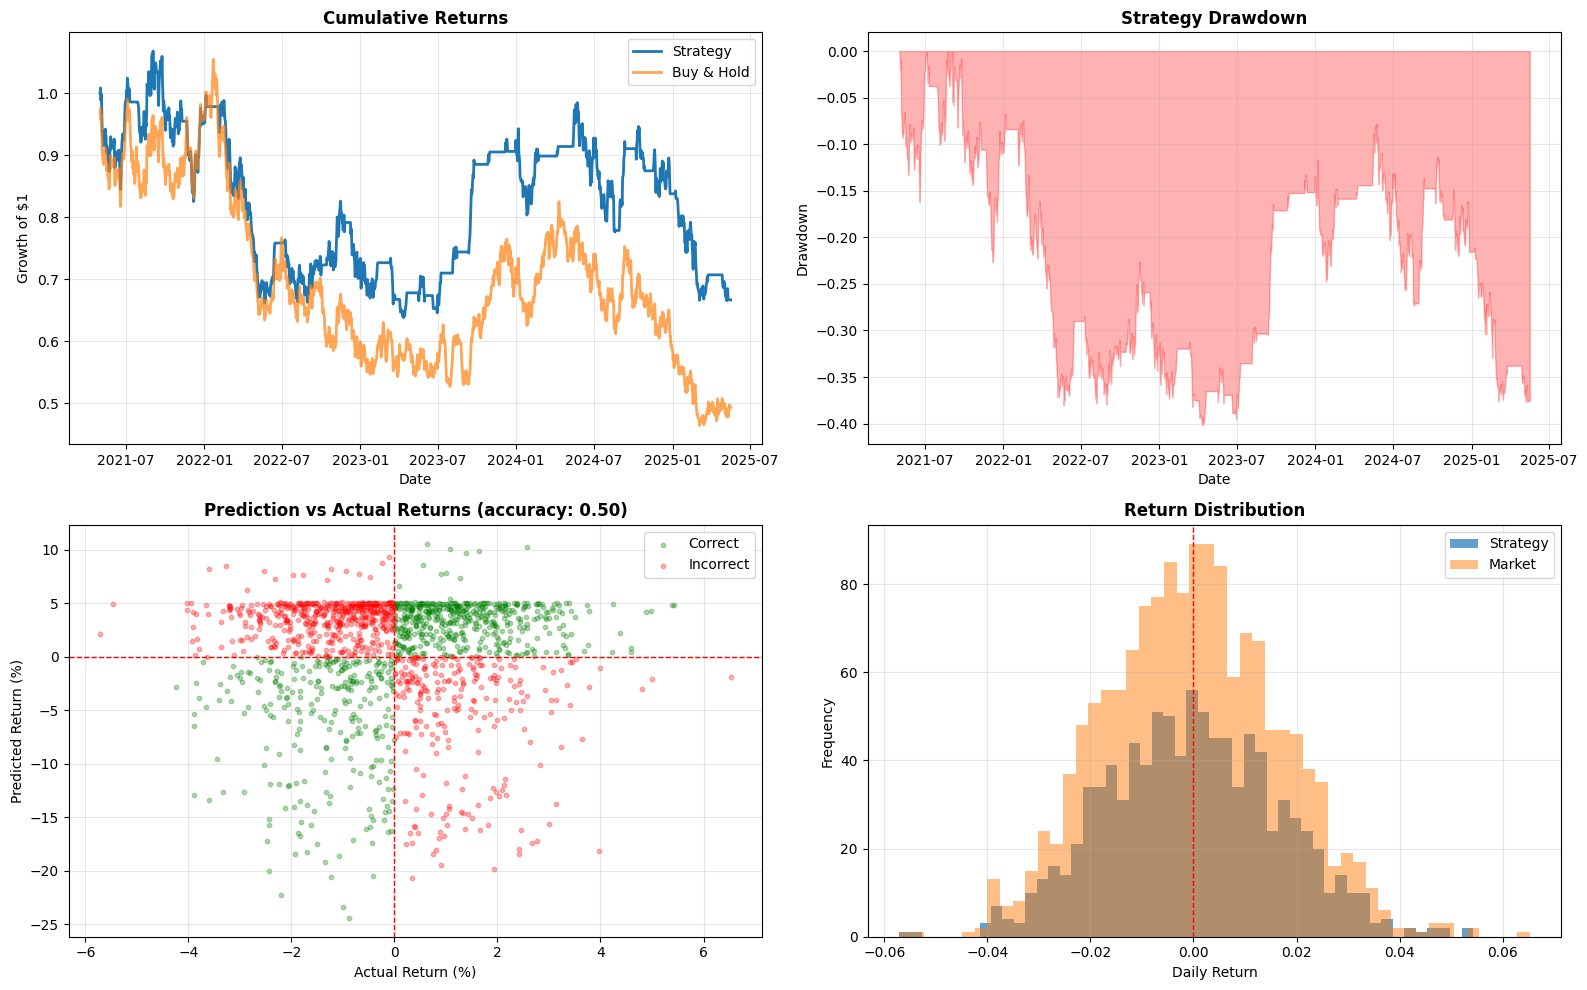

In [63]:
# Evaluate CNN strategy and visualize

cnn_model.load_state_dict(torch.load("best_cnn.pt", map_location=device))
cnn_model.eval()

print("\n" + "="*80)
print("CNN MODEL PERFORMANCE")
print("="*80)

strategy_metrics_cnn = evaluate_and_visualize_model(cnn_model, test_cnn_loader, test_df, device)

## Model Comparison Summary

,Model,Total Return (%),Sharpe Ratio,Max Drawdown (%)
0,MLP (Raw),-35.52,-0.204,-43.73
1,MLP (Eng),-7.01,0.032,-36.52
2,LSTM,1.83,0.102,-31.02
3,RNN (GRU),63.59,1.019,-8.51
4,Transformer,-43.03,-0.272,-52.38


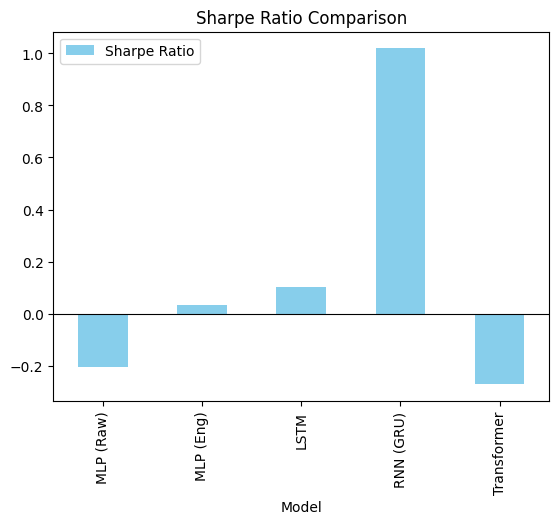

In [ ]:
# Compare all models' performance

import pandas as pd
import matplotlib.pyplot as plt
# Data collection
results = {
    "Model": ["MLP (Raw)", "MLP (Eng)", "LSTM", "RNN (GRU)", "Transformer"],
    "Total Return (%)": [-35.52, -7.01, 1.83, 63.59, -43.03],
    "Sharpe Ratio": [-0.204, 0.032, 0.102, 1.019, -0.272],
    "Max Drawdown (%)": [-43.73, -36.52, -31.02, -8.51, -52.38]
}
df_results = pd.DataFrame(results)
display(df_results)
# Visualization
df_results.plot(x="Model", y="Sharpe Ratio", kind="bar", color="skyblue", title="Sharpe Ratio Comparison")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

### Remarks and Analysis

As you might have observed, different architectures yield different performances on the stock price prediction task even if they have similar precision. Why is that and which models pull ahead in terms of financial metrics? What part of the architectures can expolain these differences?

Precision only indicates the direction of the model. In finance, Sharpe ratio and Total Return focus on how big was the impact of the correct predictions and of the mistakes. The RNN was the model that performed best, followed by the LSTM. The Transformer and MLP models did not perform well. That's because RNN and LSTM have a hidden layer that can capture the temporal dependencies and persists in time.  The RNN has a simpler function than the LSTM, which allows it to learn more efficiently from the data. Equivalently, the Transformers perform poorly because of their complexity that end up overfitting the data. MLP is limited since it cannot capture sequence.

# Hyperparameter Search and Optimization

In [95]:
import optuna
import optuna.visualization as vis
import torch.nn.functional as F


def objective(trial):
    # Hyperparameters
    hidden_dim = trial.suggest_int('hidden_dim', 32, 128)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    fc_1 = trial.suggest_int('fc_1', 16, 64)
    
    # Setup model
    model = PriceRNN(
        input_dim=len(feature_cols),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        fc_hidden_dims=[fc_1],
        dropout=dropout,
        rnn_type='GRU'
    ).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = CombinedLoss()
    
    # Train model 
    best_val_mse, _ = train_model(
        model=model, 
        train_loader=train_rnn_loader, 
        val_loader=val_rnn_loader, 
        test_loader=test_rnn_loader, 
        optimizer=optimizer, 
        loss_fn=loss_fn, 
        device=device, 
        save_path="trial_temp.pt", 
        max_epochs=10, 
        patience=5, 
        print_every=100 
    )
    
    return best_val_mse
# Create and run study
study = optuna.create_study(direction='minimize')
print("Starting hyperparameter optimization search...")
study.optimize(objective, n_trials=15) 
print("\nBest trial:")
trial = study.best_trial
print(f"  Value (MSE): {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2026-03-01 00:35:05,563] A new study created in memory with name: no-name-065fc199-8caa-496e-ad60-de6eee3b153d


Starting hyperparameter optimization search...

Training PriceRNN started...
Epoch 01 | Train MSE: 0.486577 | Val MSE: 0.485256 | Train Acc: 49.53% | Val Acc: 51.15% | Patience: 5

Early stopping at epoch 7

Best validation MSE: 0.485242, Test MSE: 0.485241
Test directional accuracy: 51.35%


[I 2026-03-01 00:35:33,437] Trial 0 finished with value: 0.4852420131043706 and parameters: {'hidden_dim': 84, 'num_layers': 3, 'learning_rate': 0.0025917882350580982, 'dropout': 0.3809257760251531, 'fc_1': 30}. Best is trial 0 with value: 0.4852420131043706.



Training PriceRNN started...
Epoch 01 | Train MSE: 0.486513 | Val MSE: 0.485124 | Train Acc: 50.50% | Val Acc: 51.01% | Patience: 5


[I 2026-03-01 00:35:51,732] Trial 1 finished with value: 0.48509532772255975 and parameters: {'hidden_dim': 56, 'num_layers': 2, 'learning_rate': 0.0005794756869823703, 'dropout': 0.3573288184555987, 'fc_1': 17}. Best is trial 1 with value: 0.48509532772255975.


...


Early stopping at epoch 8

Best validation MSE: 0.485244, Test MSE: 0.485166
Test directional accuracy: 51.35%

Training PriceRNN started...


c:\Users\eleni\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning:

dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3194085597609361 and num_layers=1



Epoch 01 | Train MSE: 0.486109 | Val MSE: 0.485147 | Train Acc: 50.51% | Val Acc: 51.89% | Patience: 5


[I 2026-03-01 00:40:17,232] Trial 14 finished with value: 0.4851473723506799 and parameters: {'hidden_dim': 76, 'num_layers': 1, 'learning_rate': 0.00029591245386136246, 'dropout': 0.3194085597609361, 'fc_1': 16}. Best is trial 11 with value: 0.4850559878526268.



Early stopping at epoch 6

Best validation MSE: 0.485147, Test MSE: 0.485183
Test directional accuracy: 52.43%

Best trial:
  Value (MSE): 0.4850559878526268
  Params: 
    hidden_dim: 64
    num_layers: 1
    learning_rate: 0.00026179361147699737
    dropout: 0.28852357524191374
    fc_1: 19


# Real Stock Data Prediction

As you may have understood, the models we have trained so far used synthetic data generated to mimic stock price movements. While this approach is useful for understanding model behavior and performance in a controlled environment, the ultimate goal is to apply these models to real-world stock data.

Why would that be difficult ? What challenges arise if you where to use this algorithm to trade in real-life markets ?

When transitioning in real-world data difficulties arise regarding generalization. Training the model on synthetic data that is described by stationary mathematical distributions does not always repsond well in real data. Especially for financial data, were there is so much noise around stock prices due to unpredicatble factors (market conditions, news, regulations, etc.). Finally, an important challenge is always overfitting. Having created the perfect model that runs on synthetic data may be actually an overfitted model, that will perform poorly in any other, different dataset.

C:\Users\eleni\AppData\Local\Temp\ipykernel_18892\2574597141.py:17: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Train samples: 2027
Val samples: 666
Test samples: 666

Input shape: (15, 9) = 15 hours x 9 features

Training fresh GRU on META

Training PriceRNN started...
Epoch 01 | Train MSE: 0.487144 | Val MSE: 0.488883 | Train Acc: 51.26% | Val Acc: 49.85% | Patience: 5
Epoch 05 | Train MSE: 0.485596 | Val MSE: 0.486848 | Train Acc: 52.70% | Val Acc: 49.85% | Patience: 2

Early stopping at epoch 7

Best validation MSE: 0.486047, Test MSE: 0.484999
Test directional accuracy: 53.46%

Final Results for META

STRATEGY PERFORMANCE:
--------------------------------------------------------------------------------
Total Return:           188.08%
Annualized Return:       49.24%
Annualized Vol:          35.09%
Sharpe Ratio:             1.314
Max Drawdown:           -34.15%
Win Rate:                53.38%
Active Days:                665 / 666

--------------------------------------------------------------------------------
BUY & HOLD BENCHMARK:
-------------------------------------------------------------

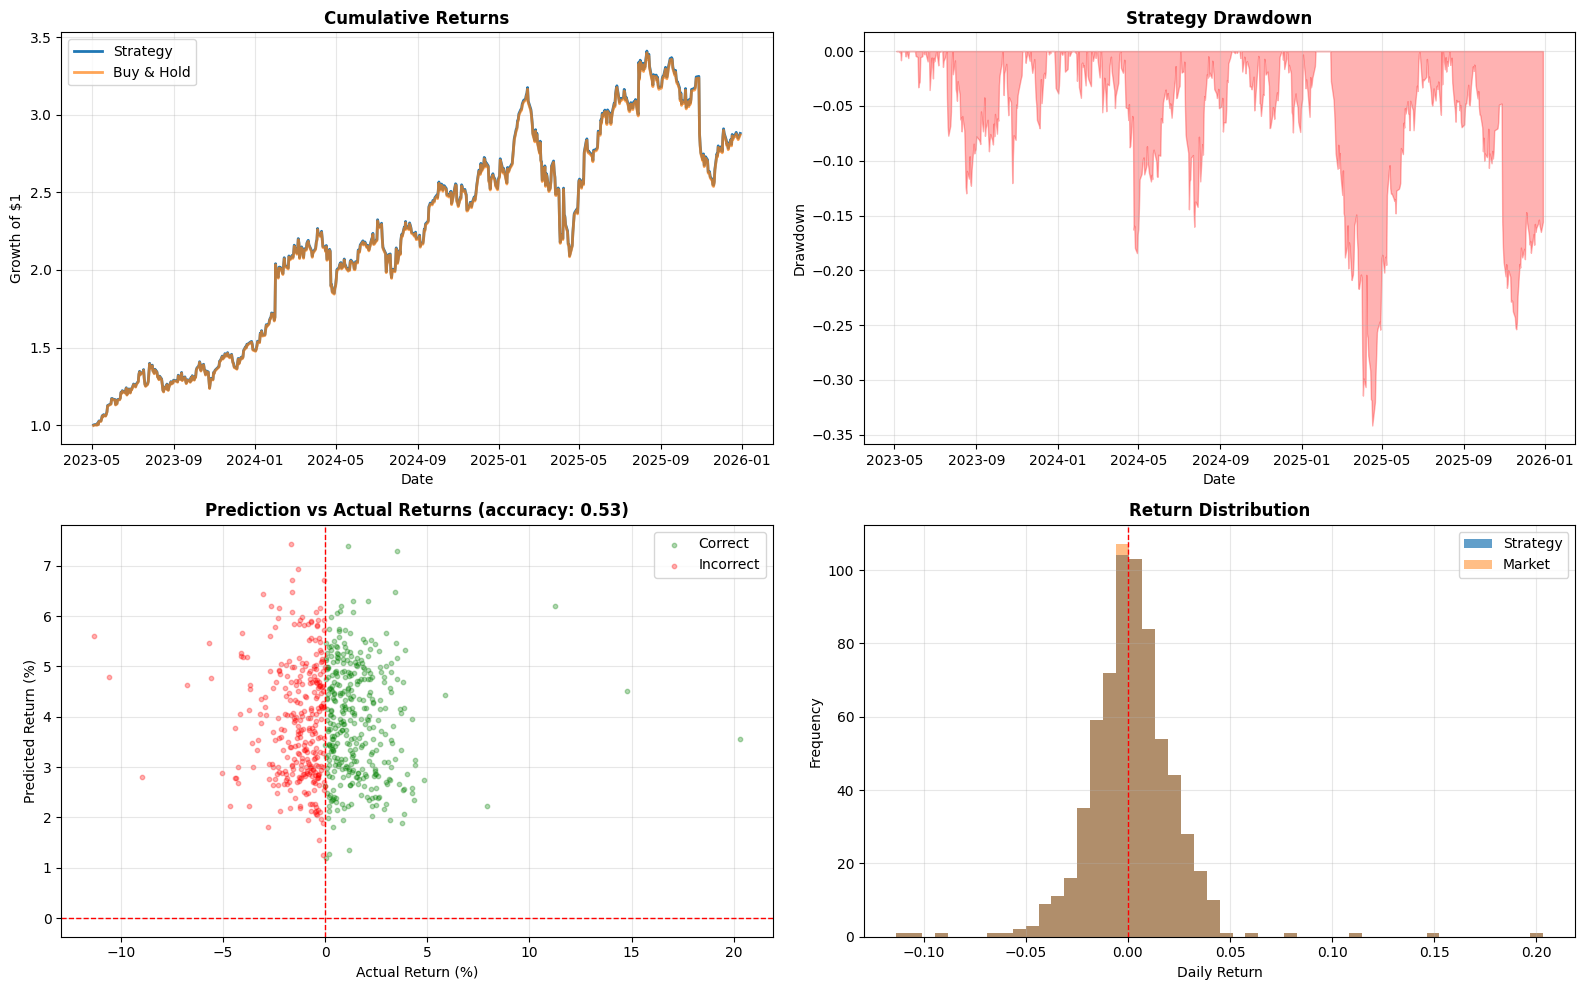

In [94]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from library import (
    split_train_val_test, 
    create_train_val_test_loaders, 
    train_model, 
    CombinedLoss, 
    evaluate_and_visualize_model
)

# Download and Preprocess Data
ticker = "META"
print(f"Downloading {ticker} Data")
real_df = yf.download(ticker, start="2012-01-01", end="2025-12-31")

if isinstance(real_df.columns, pd.MultiIndex):
    real_df.columns = real_df.columns.get_level_values(0)

df_real = real_df.copy()
df_real['volume'] = df_real['Volume']
df_real['close'] = df_real['Close']
df_real['return'] = df_real['close'].pct_change()
df_real['target_ret_next'] = df_real['return'].shift(-1)

# Feature Engineering
delta = df_real['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_real['rsi_14'] = 100 - (100 / (1 + rs))
for window in [5, 10, 20]:
    df_real[f'vol_{window}'] = df_real['close'].rolling(window=window).std()
for window in [10, 20, 50]:
    df_real[f'ema_{window}'] = df_real['close'].ewm(span=window, adjust=False).mean()
df_real = df_real.dropna()

# Split Data (60% Train, 20% Val, 20% Test)
train_real_df, val_real_df, test_real_df = split_train_val_test(df_real, train_ratio=0.6, val_ratio=0.2)

# Create Loaders
real_train_loader, real_val_loader, real_test_loader = create_train_val_test_loaders(
    train_real_df, val_real_df, test_real_df,
    raw_price_cols=feature_columns,
    seq_len=15, 
    batch_size=32
)

# Initialize and Train
print(f"\nTraining fresh GRU on {ticker}")
real_model = PriceRNN(
    input_dim=len(feature_columns),
    hidden_dim=64,
    num_layers=2,
    fc_hidden_dims=[32, 16],
    dropout=0.2,
    rnn_type='GRU'
).to(device)

real_optimizer = torch.optim.AdamW(real_model.parameters(), lr=0.001)
real_loss_fn = CombinedLoss()

best_val_real, test_mse_real = train_model(
    model=real_model,
    train_loader=real_train_loader,
    val_loader=real_val_loader,
    test_loader=real_test_loader,
    optimizer=real_optimizer,
    loss_fn=real_loss_fn,
    device=device,
    save_path="best_real_meta.pt",
    max_epochs=20, 
    patience=5
)

# Evaluate and Visualize
print(f"\nFinal Results for {ticker}")
strategy_metrics_real_final = evaluate_and_visualize_model(real_model, real_test_loader, test_real_df, device)
